In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd 
from pathlib import Path
import seamless_3dep as s3dep
import rioxarray as rxr
import py3dep
import pickle
from shapely.geometry import Polygon
import xarray as xr

In [2]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [3]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

### Access 3DEP elevation data for plotting site fig

In [4]:
sierras_bbox = (-117.862654, 34.818611, -121.948903, 40.446988)

In [5]:
sierras.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
exploded_gdf = sierras.explode()

In [5]:
exploded_gdf_5070 = exploded_gdf.to_crs(epsg=5070)

In [6]:
exploded_gdf_5070['Area2'] = exploded_gdf_5070.geometry.area / 1e6  # in sq km

In [7]:
exploded_gdf['Area2'] = exploded_gdf_5070['Area2']

In [8]:
sierra_simplified = exploded_gdf[exploded_gdf['Area2'] == exploded_gdf['Area2'].max()]

<Axes: >

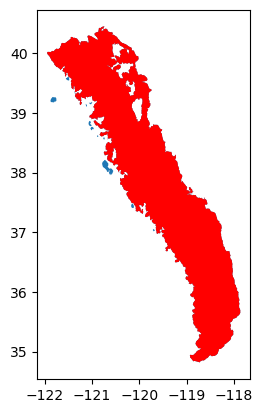

In [8]:
fig, ax = plt.subplots()
sierras.plot(ax=ax)
sierra_simplified.plot(ax=ax, color='red')

In [9]:
#sierra_simplified.to_file('../../data/misc/sierra_simplified.geojson', driver='GeoJSON')

In [9]:
#dem_200 = py3dep.get_map("DEM", sierra_simplified.geometry[0], resolution=200, geo_crs=4326, crs=4326)

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

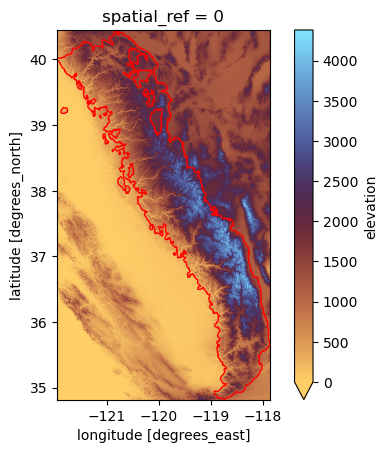

In [22]:
fig, ax = plt.subplots()

dem_200.plot(ax=ax, cmap='managua', vmin=0)
sierras.plot(ax=ax, facecolor="none", edgecolor="red")

In [10]:
#sierras_200 = dem_200.rio.clip(sierra_simplified.geometry, sierras.crs, drop=True)

In [61]:
#sierras_200.to_netcdf('../../data/3dep/dem_200m_sierras.nc')

In [14]:
sierras_200 = xr.open_dataset('../../data/3dep/dem_200m_sierras.nc')

In [15]:
sierras_200 = sierras_200.rio.write_crs('epsg:4326', inplace=True)

In [16]:
sierra_simplified_200 = sierras_200.rio.clip(sierra_simplified.geometry, sierras.crs, drop=True)

Text(0.5, 1.0, '')

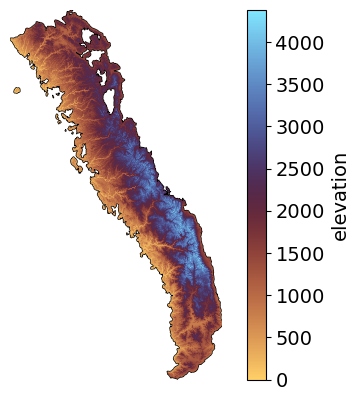

In [57]:
fig, ax = plt.subplots()

sierras_200.elevation.plot(ax=ax, cmap='managua', vmin=0, label='Elevation (m)')
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')

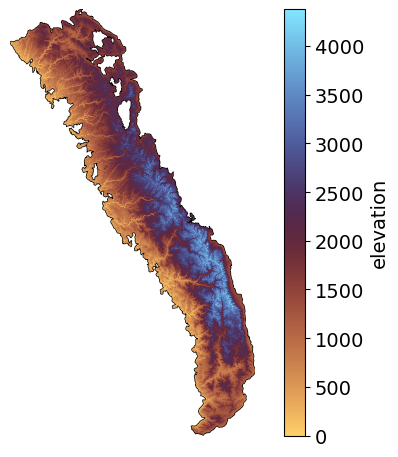

In [82]:
fig, ax = plt.subplots()

sierra_simplified_200.elevation.plot(ax=ax, cmap='managua', vmin=0, label='Elevation (m)')
sierra_simplified.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
plt.savefig('../../figures/sierras_dem_200m.png', dpi=500)

In [59]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

cax = sierras_200.elevation.plot(ax=ax[0], cmap='managua', vmin=0, vmax=4500, add_colorbar=False)
sierra_simplified.plot(ax=ax[0], facecolor="none", edgecolor="k", linewidth=0.5)
ax[0].set_axis_off()
ax[0].set_title('')

atl06sr_gdf.plot(column='h_mean', ax=ax[1], markersize=20, cmap='managua', vmin=0, vmax=4500)
sierras.plot(ax=ax[1], facecolor="none", edgecolor="k", linewidth=0.5)
ax[1].set_axis_off()
ax[1].set_title('')

cbar = fig.colorbar(cax)
cbar.set_label('Elevation (m)', size=12)

Error in callback <function flush_figures at 0x3e90ff920> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [79]:
atl06sr_gdf_simplified = atl06sr_gdf.clip(sierra_simplified.geometry)

Text(0.5, 1.0, '')

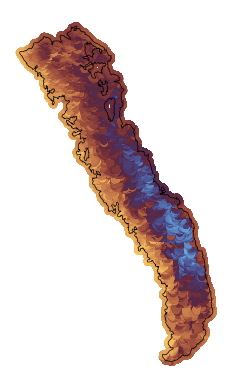

In [80]:
fig, ax = plt.subplots()

atl06sr_gdf_simplified.plot(column='h_mean', ax=ax, markersize=20, cmap='managua', vmin=0, vmax=4500)
sierra_simplified.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')



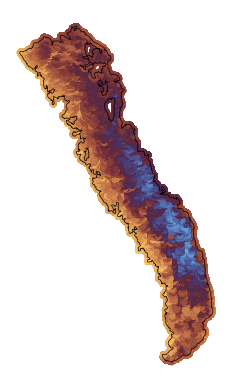

In [81]:
fig, ax = plt.subplots()

atl06sr_gdf_simplified.plot(column='h_mean', ax=ax, markersize=10, cmap='managua', vmin=0, vmax=4500)
sierra_simplified.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')

plt.savefig('../../figures/icesat2_elevation_sierras.png', dpi=500)

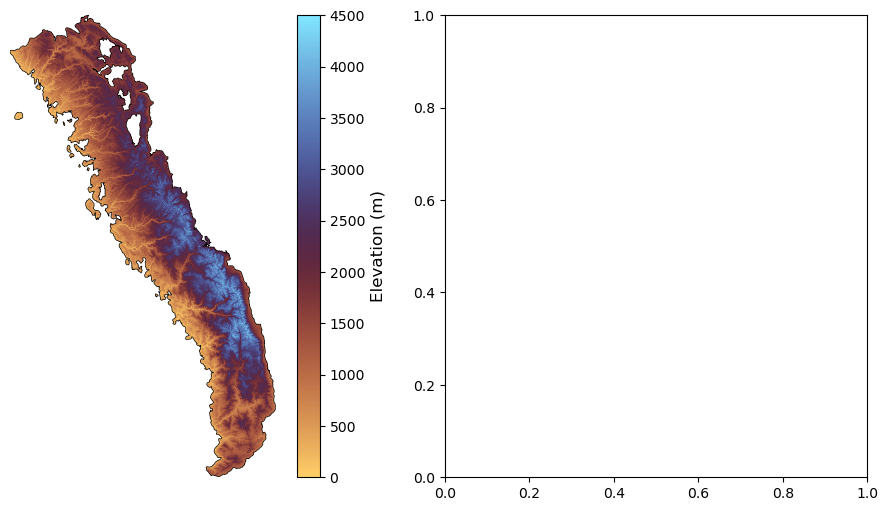

In [41]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

cax = sierras_200.plot(ax=ax[0], cmap='managua', vmin=0, vmax=4500, add_colorbar=False)
sierras.plot(ax=ax[0], facecolor="none", edgecolor="k", linewidth=0.5)
ax[0].set_axis_off()
ax[0].set_title('')

# atl06sr_gdf.plot(column='h_mean', ax=ax[1], cmap='managua', vmin=0, vmax=4500)
# sierras.plot(ax=ax[1], facecolor="none", edgecolor="k", linewidth=0.5)
# ax[1].set_axis_off()
# ax[1].set_title('')

cbar = fig.colorbar(cax)
cbar.set_label('Elevation (m)', size=12)

### Get elevation and slope for subset track:

In [17]:
import pickle

In [18]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

In [102]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask'],
      dtype='object')

In [19]:
atl06sr_gdf_snowy = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20)]
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')
atl06sr_gdf_snowy['acqdate_dt'] = pd.to_datetime(atl06sr_gdf_snowy['acqdate'])

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [43]:
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01']

In [44]:
highlight_index = 2

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [45]:
subset_bbox = (min_x, min_y, max_x, max_y)

In [46]:
subset_dem_10 = py3dep.get_map("DEM", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

TimeoutError: 

In [47]:
subset_dem_20 = py3dep.get_map("DEM", subset_bbox, resolution=20, geo_crs=4326, crs=4326)

In [ ]:
subset_dem_10.to_file('../../data/misc/inset_slope_10m.geojson', driver='GeoJSON')

### Plot subset with slope and snow cover:

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

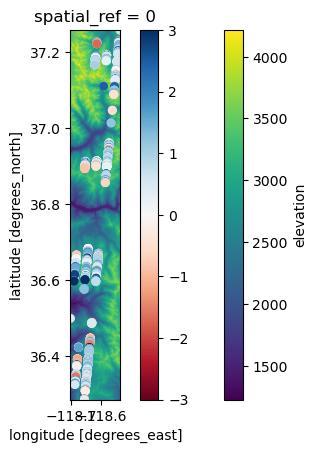

In [111]:
fig, ax =plt.subplots()
subset_dem_10.plot(ax=ax)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[2]].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1


In [12]:
slope_crs = py3dep.get_map("Slope Degrees", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

### Do the same for April 7 instead of April 1, since it's a better track to show different key points

In [31]:
alt_highlight = pd.to_datetime('2021-04-07')

In [32]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [33]:
subset_bbox = (min_x, min_y, max_x, max_y)

In [34]:
slope_crs_alt = py3dep.get_map("Slope Degrees", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

TimeoutError: 

In [17]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [18]:
atl06sr_gdf_20slope = atl06sr_gdf[atl06sr_gdf['slope']<20]

In [19]:
import matplotlib.colors as mcolors

### Read in snow cover data:

In [4]:
import xarray as xr

In [5]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [6]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [7]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [24]:
import matplotlib

(-118.84, -118.922)

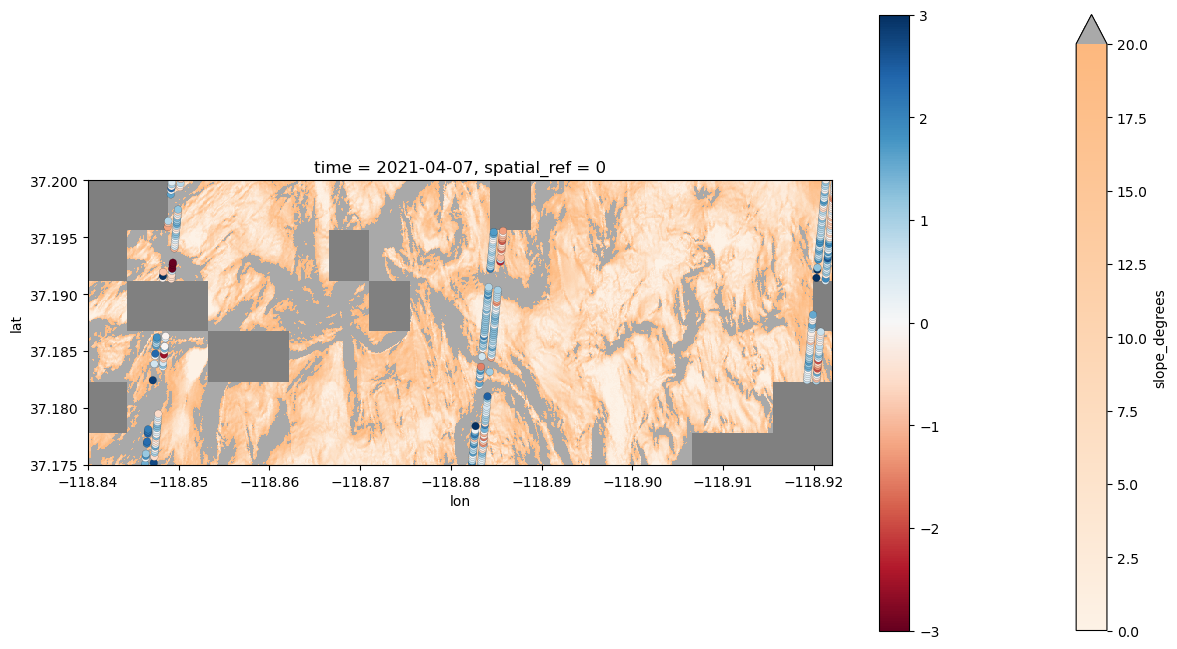

In [45]:


# 4. Plot the data using the custom norm and modified colormap
# Set the 'extend' keyword to include the 'over' color in the colorbar
# plt.imshow(data, cmap=cmap, norm=norm, extent=[0, 20, 0, 20])
# cbar = plt.colorbar(extend='max')

colors = ['#FDF2E6', '#fdb87e'] 



threshold_value = 0.9

cmap = mcolors.ListedColormap(['grey','blue', 'black'])
cmap.set_under('grey')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'darkgrey' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.84,-118.922)

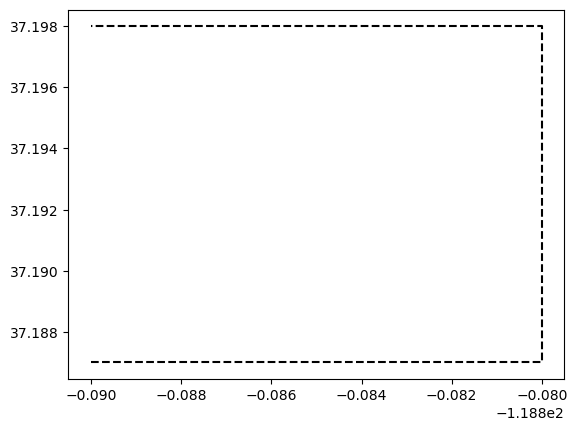

In [79]:
plt.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

In [40]:
plt.rcParams['font.size'] = 14

In [46]:
alt_highlight

Timestamp('2021-04-07 00:00:00')

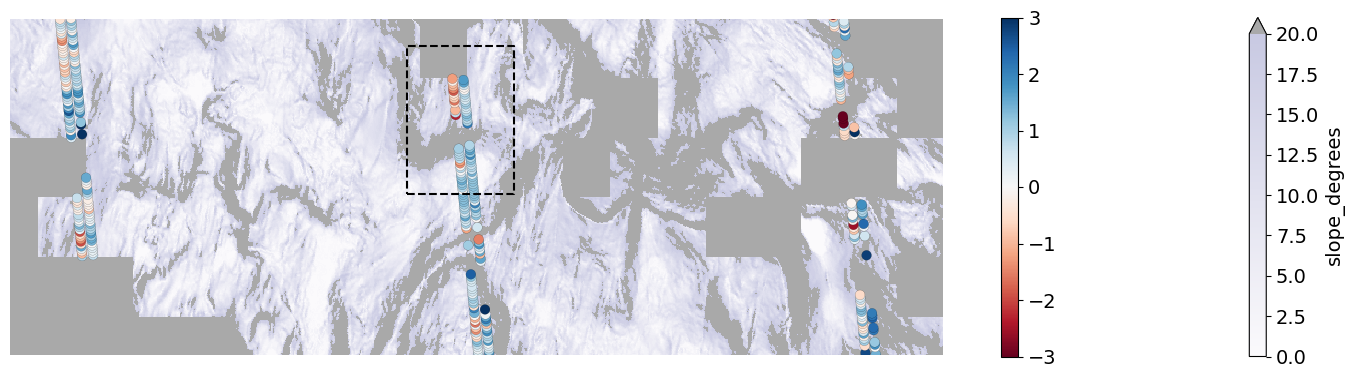

In [50]:
min_x = -118.89
min_y = 37.187
max_x = -118.88
max_y = 37.198

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']
threshold_color = '#A9A9A9'


threshold_value = 0.9

cmap = mcolors.ListedColormap([threshold_color,'blue', 'black'])
cmap.set_under(threshold_color)
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = threshold_color # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,4)) #
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy.loc[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=50, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.927,-118.84)
ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
plt.savefig('../../figures/slope_inset_6beams_april72021.png', dpi=500)

### Adjust the bounding box:

In [40]:
min_x = -118.89
min_y = 37.187 - 0.013
max_x = -118.88
max_y = 37.198 - 0.013

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']
threshold_color = '#A9A9A9'


threshold_value = 0.9

cmap = mcolors.ListedColormap([threshold_color,'blue', 'black'])
cmap.set_under(threshold_color)
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = threshold_color # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,4)) #
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy.loc[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=50, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.927,-118.84)
ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
#plt.savefig('../../figures/slope_inset_6beams_april72021.png', dpi=500)

NameError: name 'mcolors' is not defined

Text(0.5, 1.0, '')

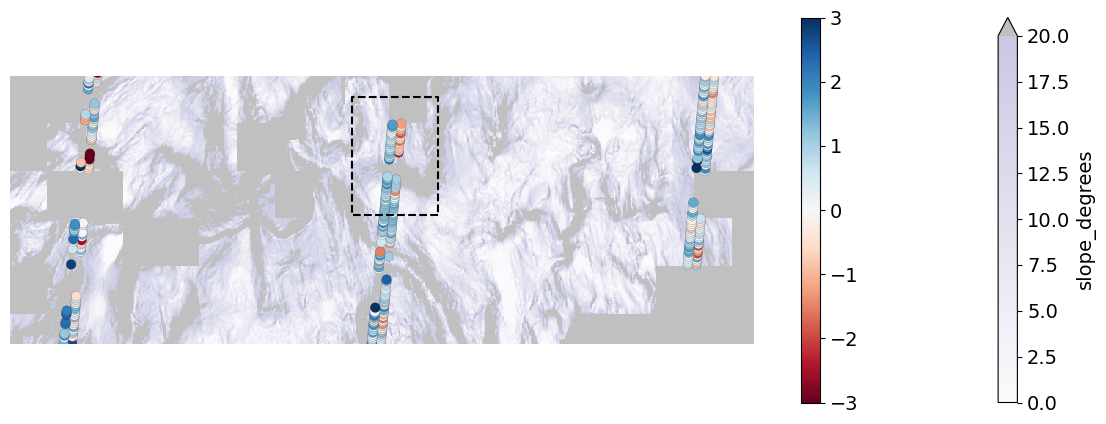

In [43]:
min_x = -118.89
min_y = 37.187
max_x = -118.88
max_y = 37.198

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']


threshold_value = 0.9

cmap = mcolors.ListedColormap(['silver','blue', 'black'])
cmap.set_under('silver')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'silver' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,5))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=50, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.84,-118.927)
ax.set_axis_off()
ax.set_title('')

In [ ]:
min_x = -118.89
min_y = 37.187
max_x = -118.88
max_y = 37.198

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']


threshold_value = 0.9

cmap = mcolors.ListedColormap(['grey','blue', 'black'])
cmap.set_under('grey')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'grey' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.84,-118.927)
ax.set_axis_off()
ax.set_title('')


Text(0.5, 1.0, '')

Error in callback <function _draw_all_if_interactive at 0x13ece0220> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

<Axes: >

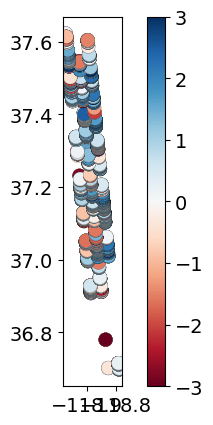

In [47]:
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(column='icesat2_3dep_dif',markersize=100, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True)

(-118.89, -118.88)

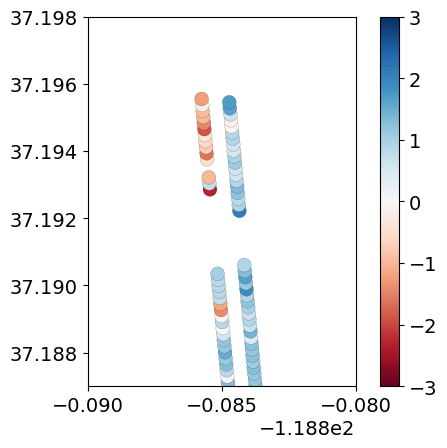

In [49]:
fig, ax = plt.subplots()

atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax,column='icesat2_3dep_dif',markersize=100, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True)
ax.set_ylim(37.187,37.198)
ax.set_xlim(-118.89,-118.88)

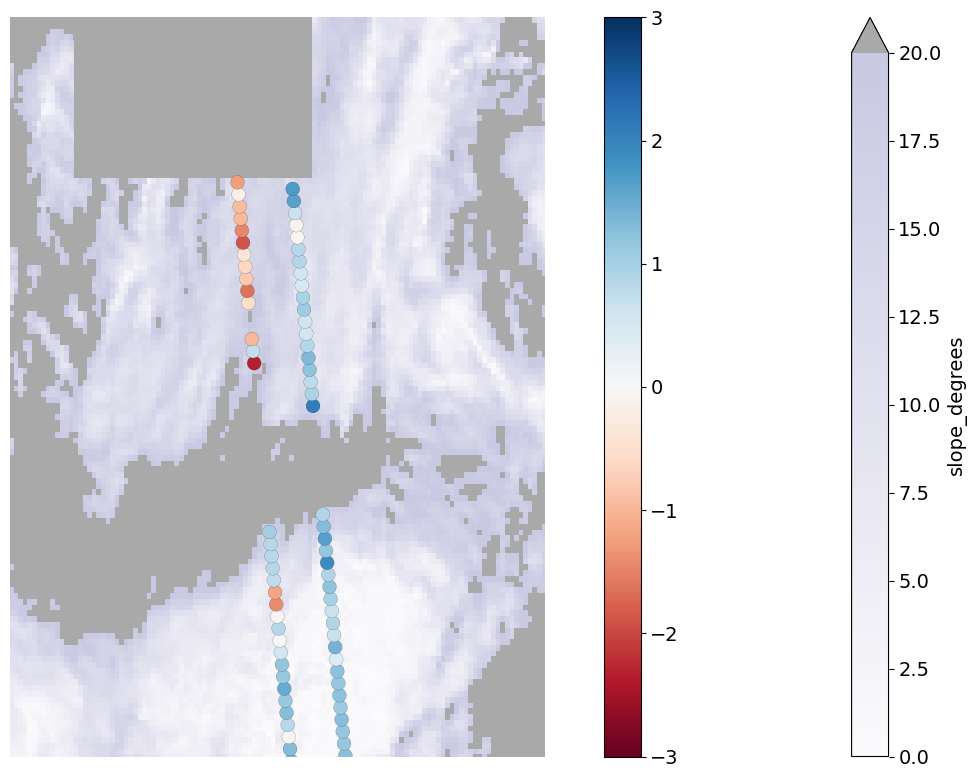

In [42]:


# 4. Plot the data using the custom norm and modified colormap
# Set the 'extend' keyword to include the 'over' color in the colorbar
# plt.imshow(data, cmap=cmap, norm=norm, extent=[0, 20, 0, 20])
# cbar = plt.colorbar(extend='max')

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']
threshold_color = '#A9A9A9'


threshold_value = 0.9

cmap = mcolors.ListedColormap([threshold_color,'blue', 'black'])
cmap.set_under(threshold_color)
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = threshold_color # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=100, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.set_ylim(37.187,37.198)
ax.set_xlim(-118.89,-118.88)
ax.set_axis_off()
ax.set_title('')


plt.tight_layout()
plt.savefig('../../figures/slope_inset_2beams_april72021.png', dpi=500)

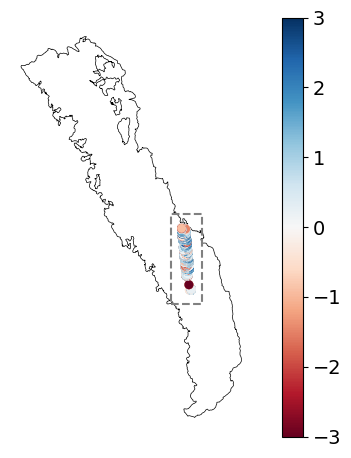

In [83]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.2

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax =plt.subplots()
sierra_simplified.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('../../figures/sierras_inset_location_april72021.png', dpi=500)

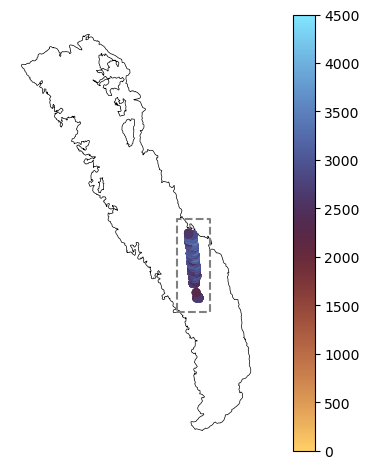

In [35]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.2

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax =plt.subplots()
sierra_simplified.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='h_mean',markersize=30, cmap='managua', legend=True, vmin=0, vmax=4500)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('../../figures/sierras_inset_location_april72021.png', dpi=500)

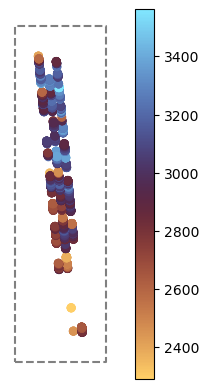

In [42]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.1

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


buffer2 = 0.05

min_x2 = -118.84 + buffer2
min_y2 = 37.175 + buffer2
max_x2 = -118.922 - buffer2
max_y2 = 37.2 - buffer2

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]


# ax.set_ylim(37.175,37.2)
# ax.set_xlim(-118.84,-118.922)


fig, ax =plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='h_mean',markersize=30, cmap='managua', legend=True)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
#ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

ax.set_axis_off()
plt.savefig('../../figures/sierras_inset_location_elevation_april72021.png', dpi=500)

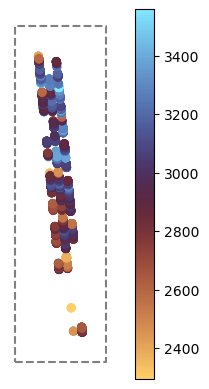

In [41]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.1

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


buffer2 = 0.05

min_x2 = -118.84 + buffer2
min_y2 = 37.175 + buffer2
max_x2 = -118.922 - buffer2
max_y2 = 37.2 - buffer2

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]


# ax.set_ylim(37.175,37.2)
# ax.set_xlim(-118.84,-118.922)


fig, ax =plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='3dep.value',markersize=30, cmap='managua', legend=True)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
#ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

ax.set_axis_off()
plt.savefig('../../figures/sierras_inset_location_3dep_elevation_april72021.png', dpi=500)

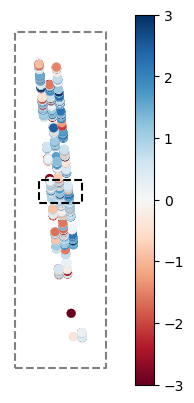

In [ ]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.1

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


buffer2 = 0.05

min_x2 = -118.84 + buffer2
min_y2 = 37.175 + buffer2
max_x2 = -118.922 - buffer2
max_y2 = 37.2 - buffer2

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]


# ax.set_ylim(37.175,37.2)
# ax.set_xlim(-118.84,-118.922)


fig, ax =plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

ax.set_axis_off()


### Get percentage of snow covered sierra that is < 20 degrees slope

In [8]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [9]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [10]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [11]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [24]:
mask

<xarray.DataArray 'SCA_Post' (lat: 1575, lon: 1125)> Size: 2MB
dask.array<gt, shape=(1575, 1125), dtype=bool, chunksize=(263, 188), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0

In [12]:
mask = mask.compute()

In [26]:
mask

<xarray.DataArray 'SCA_Post' (lat: 1575, lon: 1125)> Size: 2MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(1575, 1125))
Coordinates:
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B 0

#### Attempt to get slope for Sierras:

In [19]:
# Area of Interest
south_region1 = [
    {"lon": -119, "lat": 34.818611},
    {"lon": -117.862654, "lat": 34.818611},
    {"lon": -117.862654, "lat": 36.5},
    {"lon": -119, "lat": 36.5},
    {"lon": -119, "lat": 34.818611}
]
south_region1_poly = Polygon([(point['lon'], point['lat']) for point in south_region1])
sierra_simplified_south1 = sierra_simplified.clip(south_region1_poly)

south_region2 = [
    {"lon": -120.2, "lat": 36.5},
    {"lon": -117.862654, "lat": 36.5},
    {"lon": -117.862654, "lat": 37.5},
    {"lon": -120.2, "lat": 37.5},
    {"lon": -120.2, "lat": 36.5}
]
south_region2_poly = Polygon([(point['lon'], point['lat']) for point in south_region2])
sierra_simplified_south2 = sierra_simplified.clip(south_region2_poly)

north_region_1 = [  {"lon": -121.1, "lat": 37.5},
            {"lon": -118.5, "lat": 37.5},
            {"lon": -118.5, "lat": 39},
            {"lon": -121.1, "lat": 39},
            {"lon": -121.1, "lat": 37.5}  ]
north_region_1_poly = Polygon([(point['lon'], point['lat']) for point in north_region_1])
sierra_simplified_north1 = sierra_simplified.clip(north_region_1_poly)

north_region_2 = [  {"lon": -121.948903, "lat": 39},
            {"lon": -119.75, "lat": 39},
            {"lon": -119.75, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 39}  ]
north_region_2_poly = Polygon([(point['lon'], point['lat']) for point in north_region_2])
sierra_simplified_north2 = sierra_simplified.clip(north_region_2_poly)

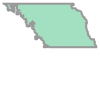

In [19]:
sierra_simplified_south2.loc[0, 'geometry']

In [20]:
slope_south_sierras = py3dep.get_map("Slope Degrees", sierra_simplified_south1.loc[0, 'geometry'], resolution=20, geo_crs=4326, crs=4326)

In [21]:
slope_south2_sierras = py3dep.get_map("Slope Degrees", sierra_simplified_south2.loc[0, 'geometry'], resolution=20, geo_crs=4326, crs=4326)

In [22]:
slope_north1_sierras = py3dep.get_map("Slope Degrees", sierra_simplified_north1.loc[0, 'geometry'], resolution=20, geo_crs=4326, crs=4326)

In [23]:
slope_north2_sierras = py3dep.get_map("Slope Degrees", sierra_simplified_north2.loc[0, 'geometry'], resolution=20, geo_crs=4326, crs=4326)

In [24]:
slope_south_sierras_allvalid = slope_south_sierras.where((slope_south_sierras != 255.0) & mask).notnull().count()

: 

In [30]:
slope_south_sierras_allvalid = slope_south_sierras.where((slope_south_sierras != 255.0) & mask).notnull().sum()
slope_south2_sierras_allvalid = slope_south2_sierras.where((slope_south2_sierras != 255.0) & mask).notnull().sum()
slope_north1_sierras_allvalid = slope_north1_sierras.where((slope_north1_sierras != 255.0) & mask).notnull().sum()
slope_north2_sierras_allvalid = slope_north2_sierras.where((slope_north2_sierras != 255.0) & mask).notnull().sum()

slope_south_sierras_under20 = slope_south_sierras.where((slope_south_sierras != 255.0) & mask & (slope_south_sierras < 20.0)).notnull().sum()
slope_south2_sierras_under20 = slope_south2_sierras.where((slope_south2_sierras != 255.0) & mask & (slope_south2_sierras < 20.0)).notnull().sum()
slope_north1_sierras_under20 = slope_north1_sierras.where((slope_north1_sierras != 255.0) & mask & (slope_north1_sierras < 20.0)).notnull().sum()
slope_north2_sierras_under20 = slope_north2_sierras.where((slope_north2_sierras != 255.0) & mask & (slope_north2_sierras < 20.0)).notnull().sum()

all_valid = slope_south_sierras_allvalid + slope_south2_sierras_allvalid + slope_north1_sierras_allvalid + slope_north2_sierras_allvalid
under_20 = slope_south_sierras_under20 + slope_south2_sierras_under20 + slope_north1_sierras_under20 + slope_north2_sierras_under20

percentage = (under_20 / all_valid) * 100 if all_valid > 0 else 0
print(percentage)

: 

In [29]:
slope_south_sierras_under20

<xarray.DataArray 'slope_degrees' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int64 8B 0

In [27]:
import xarray as xr

In [28]:
slope_sierras_20m = xr.combine_by_coords([slope_south_sierras,slope_south2_sierras,slope_north1_sierras,slope_north2_sierras])

In [ ]:
slope_sierras_20m

<xarray.Dataset> Size: 6GB
Dimensions:        (y: 32198, x: 45260)
Coordinates:
  * x              (x) float64 362kB -121.9 -121.9 -121.9 ... -117.9 -117.9
  * y              (y) float64 258kB 40.45 40.45 40.45 ... 34.82 34.82 34.82
    spatial_ref    int64 8B 0
Data variables:
    slope_degrees  (y, x) float32 6GB 255.0 255.0 255.0 ... 255.0 255.0 255.0

In [29]:
slope_sierras_20m_masked = slope_sierras_20m.where((slope_sierras_20m['slope_degrees'] != 255.0) & mask)

In [30]:
slope_sierras_20m_masked

<xarray.Dataset> Size: 10PB
Dimensions:        (y: 32198, x: 45260, lat: 1575, lon: 1125)
Coordinates:
  * x              (x) float64 362kB -121.9 -121.9 -121.9 ... -117.9 -117.9
  * y              (y) float64 258kB 40.45 40.45 40.45 ... 34.82 34.82 34.82
    spatial_ref    int64 8B 0
  * lat            (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon            (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0
Data variables:
    slope_degrees  (y, x, lat, lon) float32 10PB dask.array<chunksize=(32198, 45260, 263, 188), meta=np.ndarray>

In [31]:
slope_sierras_20m_masked_under20 = slope_sierras_20m_masked.where(slope_sierras_20m_masked['slope_degrees'] < 20.0)

In [32]:
slope_sierras_20m_masked_under20

<xarray.Dataset> Size: 10PB
Dimensions:        (y: 32198, x: 45260, lat: 1575, lon: 1125)
Coordinates:
  * x              (x) float64 362kB -121.9 -121.9 -121.9 ... -117.9 -117.9
  * y              (y) float64 258kB 40.45 40.45 40.45 ... 34.82 34.82 34.82
    spatial_ref    int64 8B 0
  * lat            (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon            (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0
Data variables:
    slope_degrees  (y, x, lat, lon) float32 10PB dask.array<chunksize=(32198, 45260, 263, 188), meta=np.ndarray>

In [33]:
total_valid_count = slope_sierras_20m_masked.slope_degrees.notnull().sum()

In [ ]:
slope_sierras_20m_masked.slope_degrees.shape

(32198, 45260)

In [35]:
total_valid_count.values

MemoryError: Unable to allocate 65.5 TiB for an array with shape (32198, 45260, 263, 188) and data type bool

: 

In [ ]:
count_under_threshold = slope_sierras_20m_masked_under20.slope_degrees.notnull().sum().item()

In [ ]:
count_under_threshold

117534546

In [ ]:
percentage = (count_under_threshold / total_valid_count) * 100 if total_valid_count > 0 else 0

In [ ]:
percentage

57.31115333964403

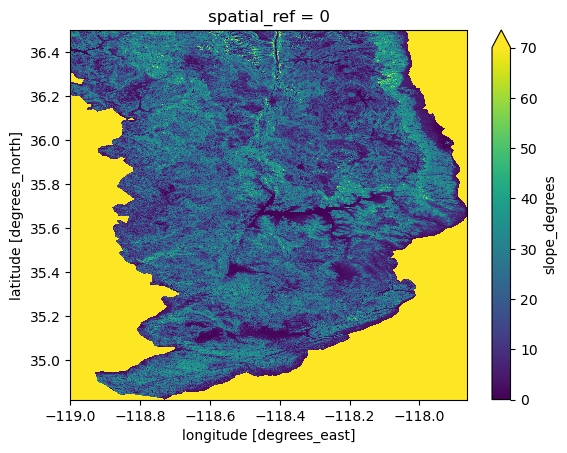

In [ ]:
slope_south_sierras.plot(vmin=0, vmax=70)

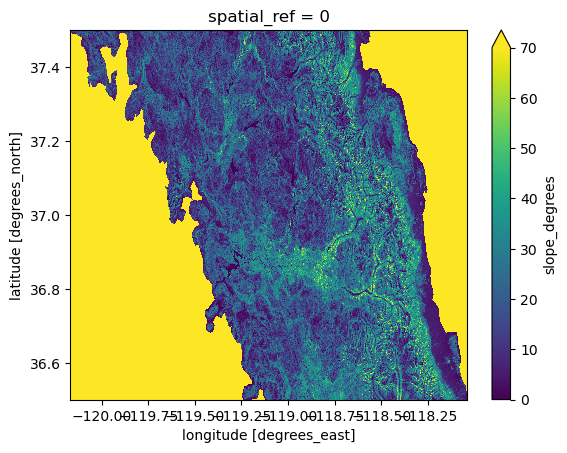

In [ ]:
slope_south2_sierras.plot(vmin=0, vmax=70)

In [ ]:
slope_south_sierras

<xarray.DataArray 'slope_degrees' (y: 9874, x: 6679)> Size: 66MB
array([[ 16,  18,  27, ..., 255, 255, 255],
       [ 16,  21,  28, ..., 255, 255, 255],
       [ 16,  16,  28, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(9874, 6679), dtype=uint8)
Coordinates:
  * x            (x) float64 53kB -119.0 -119.0 -119.0 ... -117.9 -117.9 -117.9
  * y            (y) float64 79kB 36.5 36.5 36.5 36.5 ... 34.82 34.82 34.82
    spatial_ref  int64 8B 0
Attributes:
    DataType:         Generic
    AREA_OR_POINT:    Area
    SourceBandIndex:  0
    scale_factor:     1.0
    add_offset:       0.0
    _FillValue:       255

### Reference map:

In [84]:
usa = gpd.read_file('../../data/misc/cb_2018_us_state_500k/cb_2018_us_state_500k.shp')

In [46]:
usa.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

Text(0.5, 1.0, '')

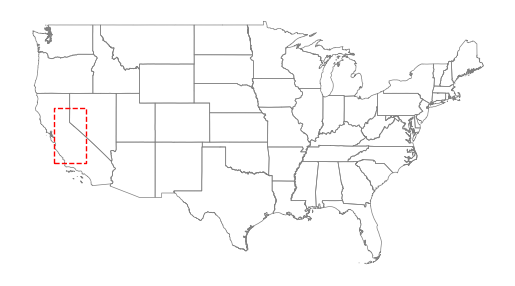

In [48]:
non_conus = ['Alaska', 'Hawaii', 'Puerto Rico', 
              'American Samoa', 'Commonwealth of the Northern Mariana Islands', 
              'Guam', 'United States Virgin Islands']

region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
usa[~usa['NAME'].isin(non_conus)].to_crs('epsg:4326').plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
ax.plot(region_lon, region_lat, linewidth=1, color='r', linestyle='--')

ax.set_axis_off()
ax.set_title('')

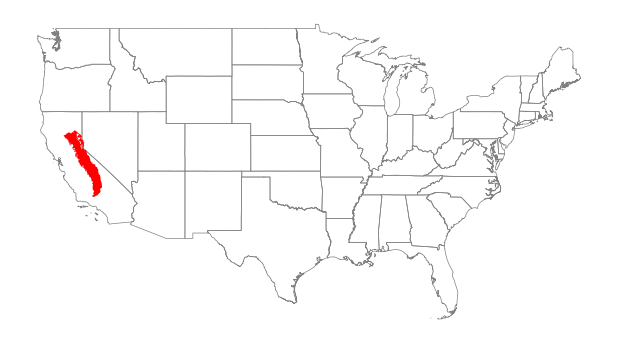

In [86]:
non_conus = ['Alaska', 'Hawaii', 'Puerto Rico', 
              'American Samoa', 'Commonwealth of the Northern Mariana Islands', 
              'Guam', 'United States Virgin Islands']

fig, ax = plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
usa[~usa['NAME'].isin(non_conus)].to_crs('epsg:4326').plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
sierra_simplified.plot(ax=ax, facecolor="red")

ax.set_axis_off()
ax.set_title('')

plt.tight_layout()
plt.savefig('../../figures/sierras_locationoutilne_us.png', dpi=500)

(32.0, 43.0)

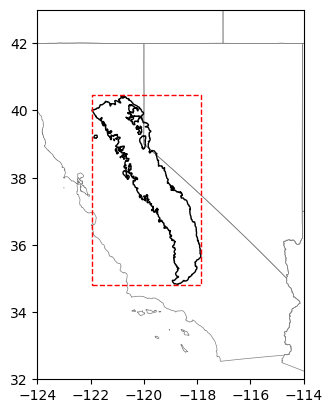

In [60]:
fig, ax = plt.subplots()
usa.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
ax.plot(region_lon, region_lat, linewidth=1, color='r', linestyle='--')
ax.set_xlim(-124, -114)
ax.set_ylim(32, 43)

### Higher resolution, probably unnecessary:

In [16]:
dem = py3dep.get_map("DEM", sierras_bbox, resolution=60, geo_crs=4326, crs=4326)

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

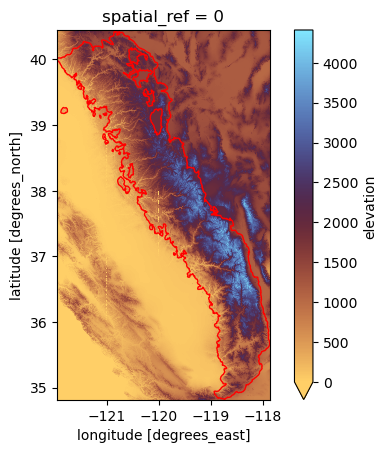

In [23]:
fig, ax = plt.subplots()

dem.plot(ax=ax, cmap='managua', vmin=0)
sierras.plot(ax=ax, facecolor="none", edgecolor="red")

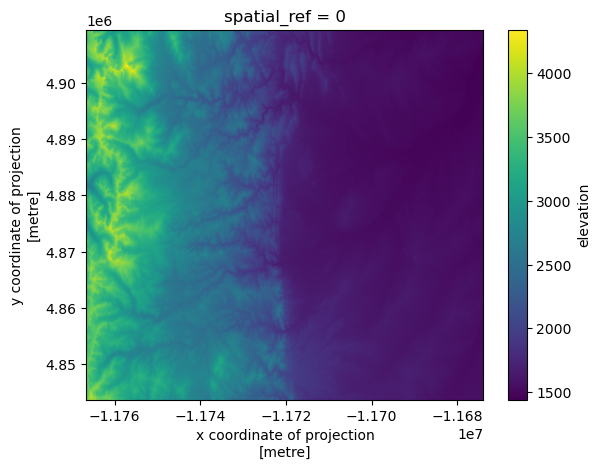

In [6]:
dem.plot()

In [ ]:
slope = py3dep.get_map("Slope Degrees", geom, resolution=30)
slope = py3dep.deg2mpm(slope)